### Get Packages

In [1]:
import pickle
import numpy as np 

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from pathlib import Path
import pandas as pd
import seaborn as sn

### Define Helper Functions

In [2]:
# Get pandas df from csv of results for each model and each test  

def get_df_from_dir(model_paths, talker=False):
    csv_str = 'metrics.csv'
    #models = [attn_models[0], ctrl_models[0]]
    bad_files = []
    dfs = []
    for model in model_paths:
        # get test csvs
        results_csvs = model.rglob("*.csv")

        for csv in results_csvs:
            try:
                df = pd.read_csv(csv)
                df['version'] = csv.as_posix().split(model.stem)[-1].split('/')[1].split('_')[-1]
                test_parts = str(model).split("/")[-1].split("_")
                #print(test_parts)
                if talker:
                    df['model'] = test_parts[2]
                    df['snr_condition'] = test_parts[3]
                    df['n_talkers'] = test_parts[0]
                else:
                    df['model'] = test_parts[0]
            #       print(test_parts)
                    df['snr_condition'] = test_parts[1]

                if len(df.filter(regex='acc_step').columns) != 0:
                    df["ACC/test_fg_acc"] = df["ACC/test_fg_acc_step"]
                    df["ACC/test_bg_acc"] = df["ACC/test_bg_acc_step"]

                dfs.append(df)
            except Exception as e:
                print(e)
                bad_files.append((csv.as_posix(), e))

    results = pd.concat(dfs, axis=0, ignore_index=True)

    # results.drop('ACC/test_fg_acc_epoch', axis=1, inplace=True)
    # results.drop('ACC/test_bg_acc_epoch', axis=1, inplace=True)
    # results.drop('epoch', axis=1, inplace=True)
    if talker:
        version_maxes = results.groupby(['model', 'snr_condition', 'n_talkers']).version.transform(max)
    else:
        version_maxes = results.groupby(['model', 'snr_condition']).version.transform(max)
    results = results[results.version == version_maxes]
    return results, bad_files 

## Make Figure with model performance

In [3]:
list(Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/').glob("*"))

[PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise'),
 PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr'),
 PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges'),
 PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_audset_bg_fully_constrained_bs_64_lr_1e-4'),
 PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_audset_bg_fully_constrained_bs_64_lr_1e-4_v2'),
 PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_multi_distractor_bs_64_lr_1e-4'),
 PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4'),
 PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_cue_jsin_pilot_no_pretrain_bs_64_lr_1e-4'),
 PosixPath('/om2/user/i

In [4]:
# bg_models = list(Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_bg_noise').glob("*"))
# snr_models = list(Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_snr_ranges').glob("*"))

# bg_results, _ = get_df_from_dir(bg_models)
# snr_results, _ = get_df_from_dir(snr_models)


talker_models = list(Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_check_n_talkers_snr').glob("*"))
talker_results, _ = get_df_from_dir(talker_models, talker=True)



No columns to parse from file
No columns to parse from file
No columns to parse from file
No columns to parse from file


In [5]:
talker_results.head()

,ACC/test_fg_acc,test_confusion,step,version,model,snr_condition,n_talkers
3208,0.750,NaN,0,6,MultiDistractorAttnCNN,-10dB,1
3209,0.500,NaN,1,6,MultiDistractorAttnCNN,-10dB,1
3210,0.500,NaN,2,6,MultiDistractorAttnCNN,-10dB,1
3211,0.375,NaN,3,6,MultiDistractorAttnCNN,-10dB,1
3212,0.875,NaN,4,6,MultiDistractorAttnCNN,-10dB,1


In [6]:
talker_results.groupby('n_talkers').snr_condition.unique()

n_talkers
1    [-10dB, -15dB, -18dB, -5dB, 0dB, 10dB, 5dB, cl...
2    [-10dB, -15dB, -18dB, -5dB, 0dB, 10dB, 5dB, cl...
3    [-10dB, -15dB, -18dB, -5dB, 0dB, 10dB, 5dB, cl...
4    [-10dB, -15dB, -18dB, -5dB, 0dB, 10dB, 5dB, cl...
5    [-10dB, -15dB, -18dB, -5dB, 0dB, 10dB, 5dB, cl...
Name: snr_condition, dtype: object

In [7]:
talker_results['model'].replace('MultiDistractorAttnCNN','speech + noise',inplace=True)


# combine strings for legend
talker_hue_tags = talker_results['model'] + ' ' + talker_results['n_talkers'] + '-distractor'
# get order of model-talker conditions 
talker_hue_order = np.sort(talker_hue_tags.unique())
# put in order for diverging color map: cue 1-4, control 4-1
# talker_hue_order = np.hstack([talker_hue_order[4:], talker_hue_order[:4][::-1]])
# set color map and get color dict
talker_cmap = sn.color_palette("coolwarm", len(talker_hue_order*2), as_cmap=False)
talker_palette = {cond:talker_cmap[ix] for ix, cond in enumerate(talker_hue_order)}
# get wanted order: cue 1-4 control 1-4
# talker_hue_order = np.hstack([talker_hue_order[:4], talker_hue_order[4:][::-1]])



In [8]:
talker_hue_order , talker_palette

(array(['speech + noise 1-distractor', 'speech + noise 2-distractor',
        'speech + noise 3-distractor', 'speech + noise 4-distractor',
        'speech + noise 5-distractor'], dtype=object),
 {'speech + noise 1-distractor': (0.4358148063058824,
   0.5707073031529412,
   0.951717381282353),
  'speech + noise 2-distractor': (0.6672529243333334,
   0.7791764569999999,
   0.992959213),
  'speech + noise 3-distractor': (0.8674276350862745,
   0.864376599772549,
   0.8626024620196079),
  'speech + noise 4-distractor': (0.968203399, 0.7208441, 0.6122929913333334),
  'speech + noise 5-distractor': (0.9057834780117647,
   0.4551856921647059,
   0.35533588384705883)})

(0.0, 1.0)

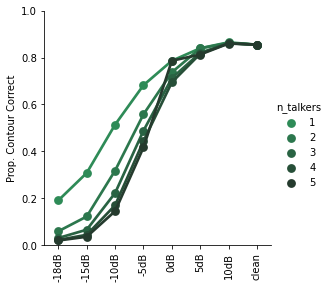

In [9]:
snr_order = ['-18dB', '-15dB', '-10dB', '-5dB', '0dB', '5dB', '10dB', 'clean']

# set single-model plots to match palette 
# model_paletts = {'cued model': sn.color_palette("coolwarm", as_cmap=False)[0],
#                  'control model': sn.color_palette("coolwarm", as_cmap=False)[-1]
# }

# fig, axs = plt.subplots(1,2, sharey=True, figsize=(5,5))
# axs = axs.ravel()


g = sn.catplot( kind='point',
    data=talker_results, 
    x='snr_condition', y='ACC/test_fg_acc',
#     col='n_talkers', col_wrap=2,
    hue='n_talkers',
#     hue_order=talker_hue_order,
#     ci=95, seed=1,
     height=4,
    palette=sns.dark_palette("seagreen", reverse=True, as_cmap=False),
               order=snr_order,
#     ax=axs[0]
)


# g2 = sn.catplot( kind='point',
#     data=talker_results, 
#     x='snr_condition', y='ACC/test_fg_acc',
# #     col='n_talkers', col_wrap=2,
#     hue='n_talkers',
# #     hue_order=talker_hue_order,
# #     ci=95, seed=1,
# #                  height=3,
#     palette=sns.dark_palette("seagreen", reverse=True, as_cmap=False),
#                order=snr_order,
#     ax=axs[1]
# )

# # g3.title("Performance on multi-distractor mixtures")


# g3.set_ylabel("Prop. target word correct")


# g3.set_ylim((0,1))


# axs.legend(title='', ncol=2, bbox_to_anchor=(1, 0.5), frameon=False)


# plt.tight_layout()


g.set_xticklabels(rotation=90)
g.set_axis_labels("", "Prop. Contour Correct")
plt.ylim(0, 1)
